In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Import pandas library first
import pandas as pd

# Now you can use pd.read_csv
df = pd.read_csv("Supermart Grocery Sales - Retail Analytics Dataset (1).csv")
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [3]:
df.isnull().sum()


Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

In [4]:
df.dropna(inplace=True)


In [5]:
df['Sales Amount'] = df['Sales']


In [6]:
print("Total Sales: ", df['Sales Amount'].sum())
print("Total Orders: ", df['Order ID'].nunique())
print("Average Sales: ", df['Sales Amount'].mean())


Total Sales:  14956982
Total Orders:  9994
Average Sales:  1496.5961576946167


In [7]:
df.groupby('Category')['Sales Amount'].sum().sort_values(ascending=False)


Category
Eggs, Meat & Fish    2267401
Snacks               2237546
Food Grains          2115272
Bakery               2112281
Fruits & Veggies     2100727
Beverages            2085313
Oil & Masala         2038442
Name: Sales Amount, dtype: int64

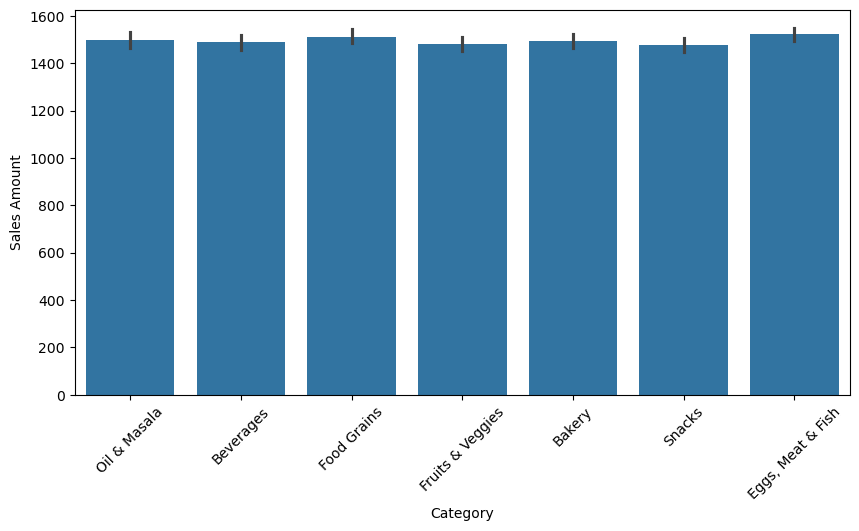

In [8]:
# Import the required libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Now create the plot
plt.figure(figsize=(10,5))
sns.barplot(x='Category', y='Sales Amount', data=df)
plt.xticks(rotation=45)
plt.show()

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], infer_datetime_format=True, dayfirst=True, errors='coerce')


C:\Users\Admin\AppData\Local\Temp\ipykernel_10592\3222104112.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Order Date'] = pd.to_datetime(df['Order Date'], infer_datetime_format=True, dayfirst=True, errors='coerce')


In [10]:
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales Amount'].sum()
monthly_sales


Month
1.0     500142
2.0     571073
3.0     564417
4.0     451341
5.0     555101
6.0     421339
7.0     430447
8.0     535192
9.0     526866
10.0    449496
11.0    533791
12.0    514295
Name: Sales Amount, dtype: int64

<Axes: xlabel='Month'>

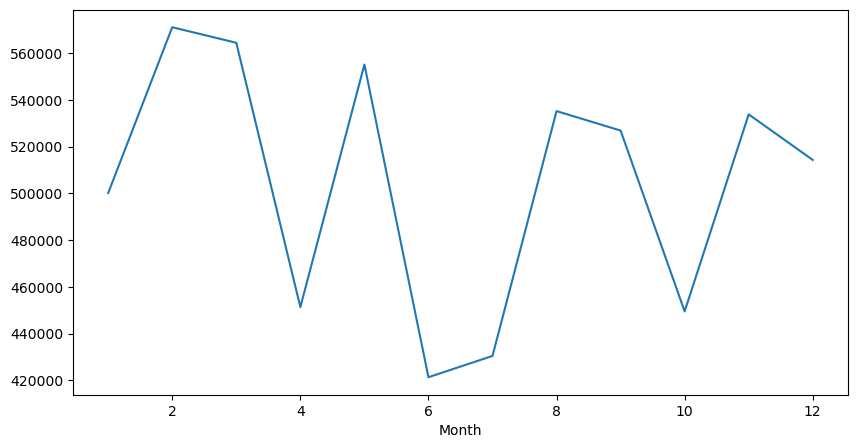

In [11]:
monthly_sales.plot(kind='line', figsize=(10,5))


In [12]:
df.to_csv("cleaned_supermart_sales.csv", index=False)


In [13]:
df.describe()


,Order Date,Sales,Discount,Profit,Sales Amount,Month
count,4042,9994.000000,9994.000000,9994.000000,9994.000000,4042.000000
mean,2017-03-12 21:47:06.917367808,1496.596158,0.226817,374.937082,1496.596158,6.452499
min,2015-01-02 00:00:00,500.000000,0.100000,25.250000,500.000000,1.000000
25%,2016-04-04 06:00:00,1000.000000,0.160000,180.022500,1000.000000,3.000000
50%,2017-05-02 00:00:00,1498.000000,0.230000,320.780000,1498.000000,6.000000
75%,2018-03-06 00:00:00,1994.750000,0.290000,525.627500,1994.750000,9.000000
max,2018-12-11 00:00:00,2500.000000,0.350000,1120.950000,2500.000000,12.000000
std,NaN,577.559036,0.074636,239.932881,577.559036,3.501948


In [14]:
df['Sales Amount'].sum()


14956982

In [15]:
df['Profit'].sum()


3747121.1999999997

In [16]:
df['Order ID'].nunique()


9994

In [17]:
df.groupby('Category')['Sales Amount'].sum()


Category
Bakery               2112281
Beverages            2085313
Eggs, Meat & Fish    2267401
Food Grains          2115272
Fruits & Veggies     2100727
Oil & Masala         2038442
Snacks               2237546
Name: Sales Amount, dtype: int64

In [18]:
df[['Order Date','Month']].head(100)


,Order Date,Month
0,2017-08-11,8.0
1,2017-08-11,8.0
2,2017-12-06,12.0
3,2016-11-10,11.0
4,2016-11-10,11.0
...,...,...
95,2018-06-11,6.0
96,2018-09-11,9.0
97,NaT,NaN
98,2017-06-09,6.0


In [19]:
df = df.dropna(subset=['Order Date'])


In [20]:
df[['Order Date','Month']].head(100)


,Order Date,Month
0,2017-08-11,8.0
1,2017-08-11,8.0
2,2017-12-06,12.0
3,2016-11-10,11.0
4,2016-11-10,11.0
...,...,...
213,2016-02-01,2.0
214,2016-02-01,2.0
215,2016-02-01,2.0
216,2016-02-01,2.0


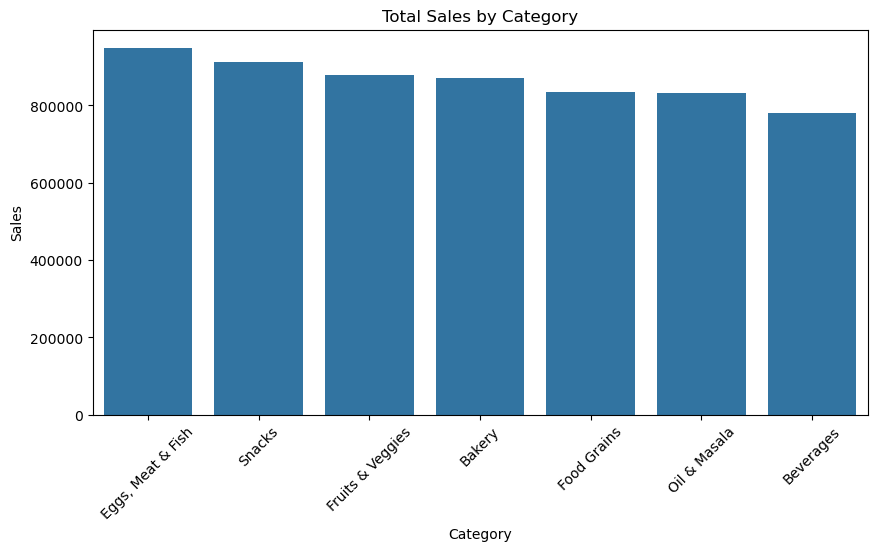

In [21]:
category_sales = df.groupby('Category')['Sales Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


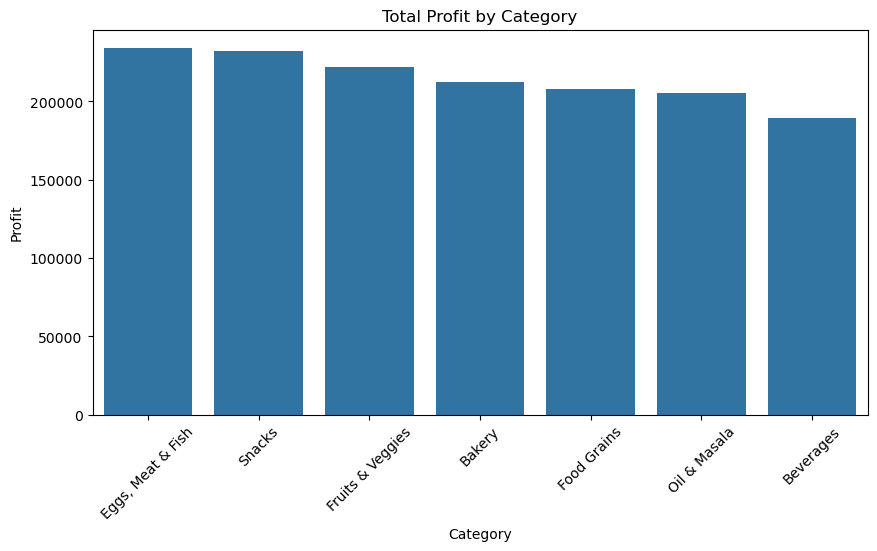

In [22]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=category_profit.index, y=category_profit.values)
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()


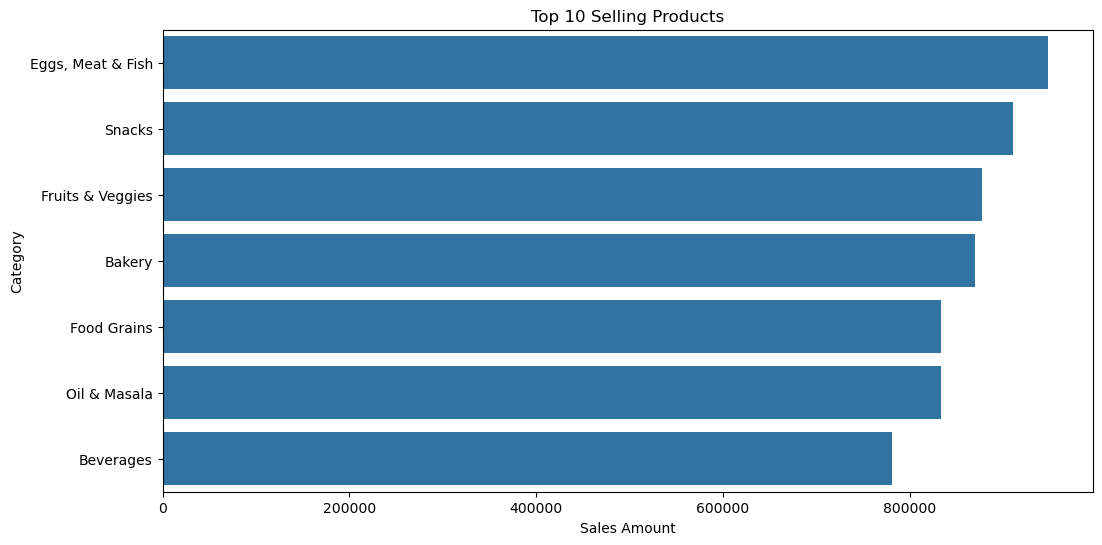

In [23]:
top_products = df.groupby('Category', dropna=True)['Sales Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(y=top_products.index, x=top_products.values)
plt.title("Top 10 Selling Products")
plt.xlabel("Sales Amount")
plt.ylabel("Category")
plt.show()


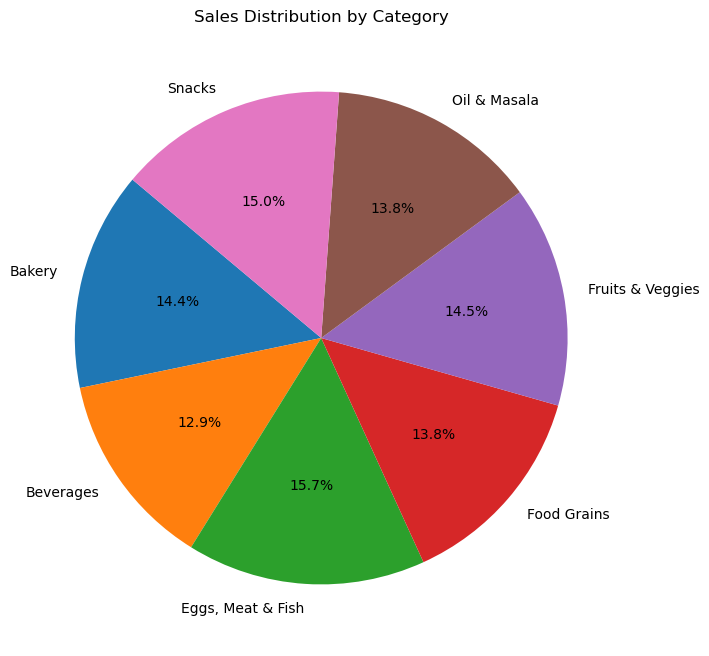

In [24]:
category_sales = df.groupby('Category')['Sales Amount'].sum()

plt.figure(figsize=(8,8))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140)
plt.title("Sales Distribution by Category")
plt.show()


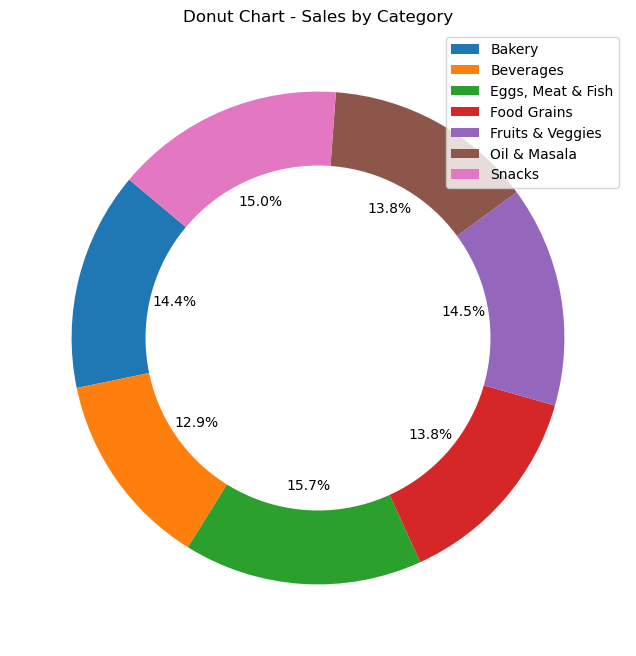

In [25]:
category_sales = df.groupby('Category')['Sales Amount'].sum()

plt.figure(figsize=(8,8))
wedges, texts, autotexts = plt.pie(
    category_sales,
    autopct='%1.1f%%',
    startangle=140,
    textprops=dict(color="black")
)

# Draw a circle in the middle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Donut Chart - Sales by Category")
plt.legend(category_sales.index, loc="best")
plt.show()
